In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data_processed/master_test_dataset.csv")

df['date'] = pd.to_datetime(df['date'])

df.head(2)

,match_id,team1,team2,venue,city,date,winner,win_by_runs,win_by_wickets,year,result_type,host_country,home_team,away_team,opponent
0,1000851,Australia,South Africa,Western Australia Cricket Association Ground,Perth,2016-11-03,South Africa,177.0,NaN,2016,Win,Australia,Australia,South Africa,Australia
1,1000853,Australia,South Africa,Bellerive Oval,Hobart,2016-11-12,South Africa,80.0,NaN,2016,Win,Australia,Australia,South Africa,Australia


In [2]:
country = "India"

start_year = 2015
end_year = 2025

df_country = df[
    (df["team1"] == country) |
    (df["team2"] == country)
].copy()

df_country = df_country[
    (df_country["year"] >= start_year) &
    (df_country["year"] <= end_year)
]

In [3]:
df_country['opponent'] = df_country.apply(
    lambda row : row['team2']
    if row['team1'] == country
    else row['team1'],
    axis = 1
)

In [4]:
def get_result(row):
    if row['winner'] == country:
        return 'Win'
    elif pd.isna(row['winner']):
        return 'Draw'
    else:
        return 'Loss'
    
df_country["result"] = df_country.apply(get_result, axis=1)

In [16]:
df_away = df_country[df_country["away_team"] == country].copy()


In [6]:
sena_countries = [
    "South Africa",
    "England",
    "New Zealand",
    "Australia"
]

df_away["region"] = df_away["opponent"].apply(
    lambda x: "SENA" if x in sena_countries else "Non-SENA"
)

sena_countries

['South Africa', 'England', 'New Zealand', 'Australia']

In [7]:
sena_summary = pd.pivot_table(
    df_away,
    values="match_id",
    index="region",
    columns="result",
    aggfunc="count",
    fill_value=0
)

sena_summary

result,Draw,Loss,Win
region,,,
Non-SENA,4,1,12
SENA,6,20,13


In [8]:
sena_summary["Total"] = (
    sena_summary["Win"] +
    sena_summary["Draw"] +
    sena_summary["Loss"]
)

sena_summary["Win_Percentage"] = (
    sena_summary["Win"] / sena_summary["Total"]
) * 100

sena_summary

result,Draw,Loss,Win,Total,Win_Percentage
region,,,,,
Non-SENA,4,1,12,17,70.588235
SENA,6,20,13,39,33.333333


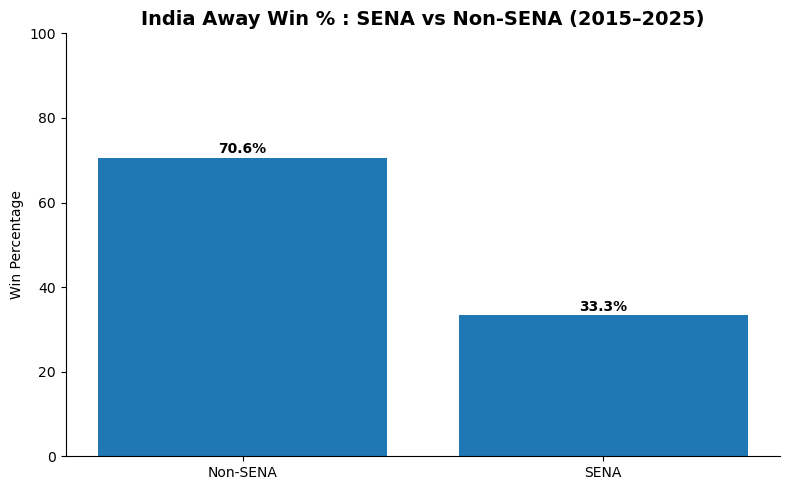

In [9]:
plt.figure(figsize=(8,5))

bars = plt.bar(
    sena_summary.index,
    sena_summary["Win_Percentage"]
)

plt.title(
    f"{country} Away Win % : SENA vs Non-SENA (2015–2025)",
    fontsize=14,
    fontweight='bold'
)

plt.ylabel("Win Percentage")
plt.xlabel("")

sns.despine()

# Labels
for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 1,
        f"{height:.1f}%",
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

plt.ylim(0, 100)
plt.tight_layout()
plt.show()

So India’s overseas dominance is highly region-dependent.

India remains dominant overall, but its overseas struggles are concentrated heavily within SENA conditions.